### Imports and Database Connection

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido
# Connect to the database 
conn = sqlite3.connect('../data/db/bluestock_mf.db')
print("Database connected successfully!")

Database connected successfully!


### NAV Trend Analysis (Plotly)

In [2]:
# Pull NAV history and join with fund details
query = """
SELECT n.date, n.nav, f.scheme_name 
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
"""
nav_df = pd.read_sql(query, conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

# Build interactive timeline chart
fig = px.line(nav_df, x='date', y='nav', color='scheme_name', 
              title='Historical NAV Trends (2022 - 2026)')

# Add financial market annotations
fig.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
              annotation_text="2023 Bull Run", annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.1, 
              annotation_text="2024 Correction", annotation_position="top left")

fig.update_layout(showlegend=False, template='plotly_dark')
fig.show()

# Save for final report export requirement
fig.write_image("../reports/nav_trends.png")

### AUM Growth Bar Chart (Seaborn)

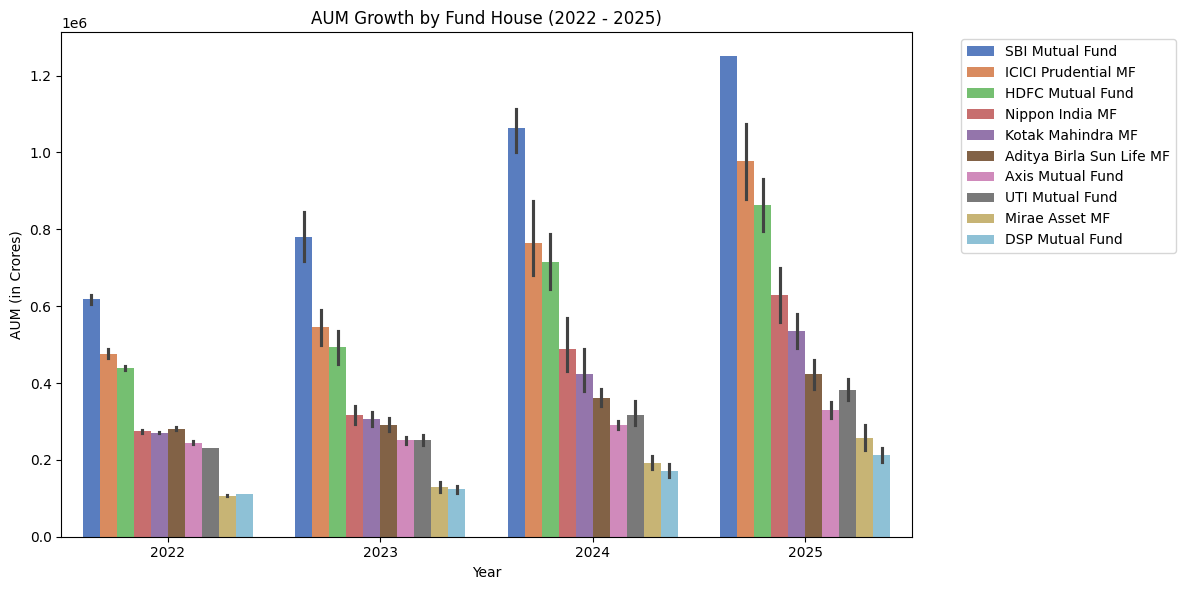

In [ ]:
plt.figure(figsize=(12, 6))
aum_df = pd.read_sql("SELECT * FROM fact_aum", conn)

# Make sure date tracks yearly blocks
aum_df['year'] = pd.to_datetime(aum_df['date']).dt.year

# Plot grouped AUM bars
sns.barplot(data=aum_df, x='year', y='aum_crore', hue='fund_house', palette='muted')

plt.title('AUM Growth by Fund House (2022 - 2025)')
plt.ylabel('AUM (in Crores)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('../reports/aum_growth.png', dpi=300)
plt.show()

### Monthly SIP Inflow Time-Series (Plotly)

In [ ]:
# Load local historical macro files from processed paths
sip_df = pd.read_csv('../data/processed/clean_monthly_sip_inflows.csv')
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(sip_df, x='month', y='sip_inflow_crore', 
              title='Monthly Total SIP Inflow Trend (2022 - 2025)', markers=True)

# Annotate the Dec 2025 milestone peak 
fig.add_annotation(x="2025-12-01", y=31002,
            text="All-Time High: ₹31,002 Cr",
            showarrow=True, arrowhead=1, ax=-100, ay=-30)

fig.update_layout(template='plotly_white')
fig.show()
fig.write_image("../reports/sip_inflows.png")

### Category Inflow Heatmap (Seaborn)

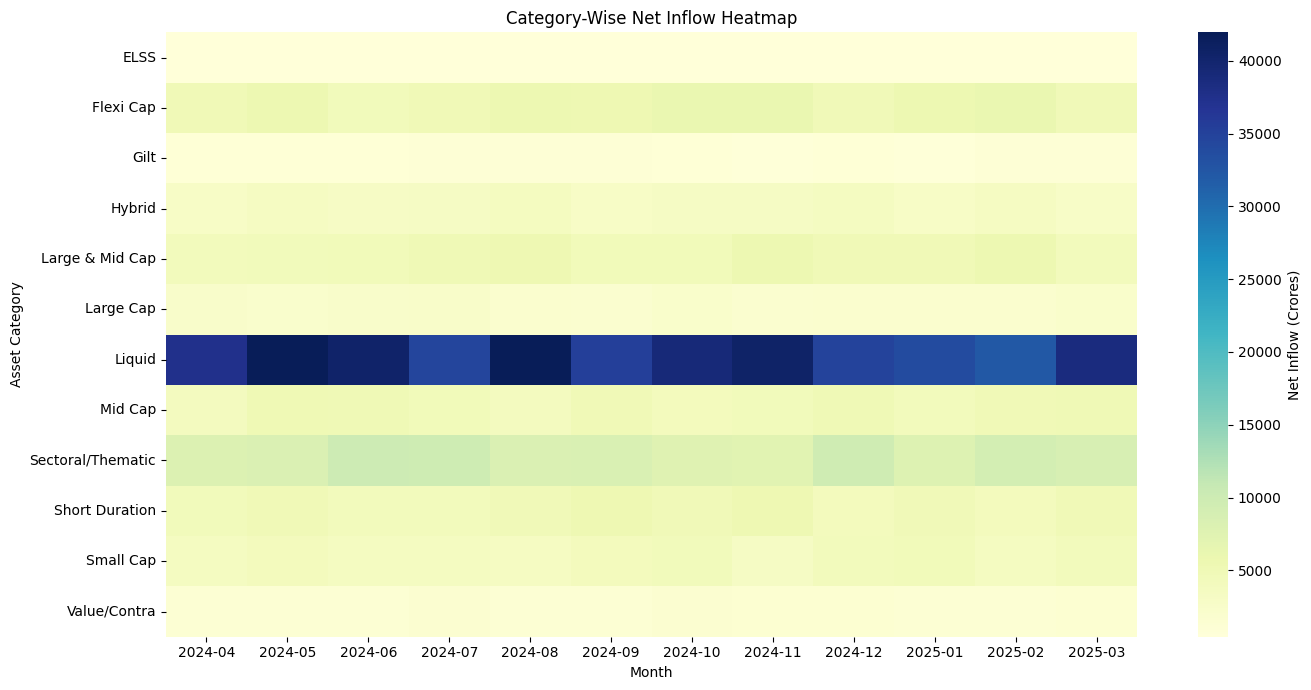

In [ ]:
plt.figure(figsize=(14, 7))
cat_df = pd.read_csv('../data/processed/clean_category_inflows.csv')

# Format pivot framework for mapping intensity
pivot_df = cat_df.pivot(index='category', columns='month', values='net_inflow_crore')

sns.heatmap(pivot_df, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Net Inflow (Crores)'})
plt.title('Category-Wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Asset Category')
plt.tight_layout()

plt.savefig('../reports/category_heatmap.png', dpi=300)
plt.show()

### Investor Demographics Analysis (Matplotlib / Seaborn)

C:\Users\Arjun\AppData\Local\Temp\ipykernel_16804\1550367224.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='gender', ax=axes[1], palette='Set2')
C:\Users\Arjun\AppData\Local\Temp\ipykernel_16804\1550367224.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_only, x='age_group', y='amount_inr', ax=axes[2], palette='Accent')


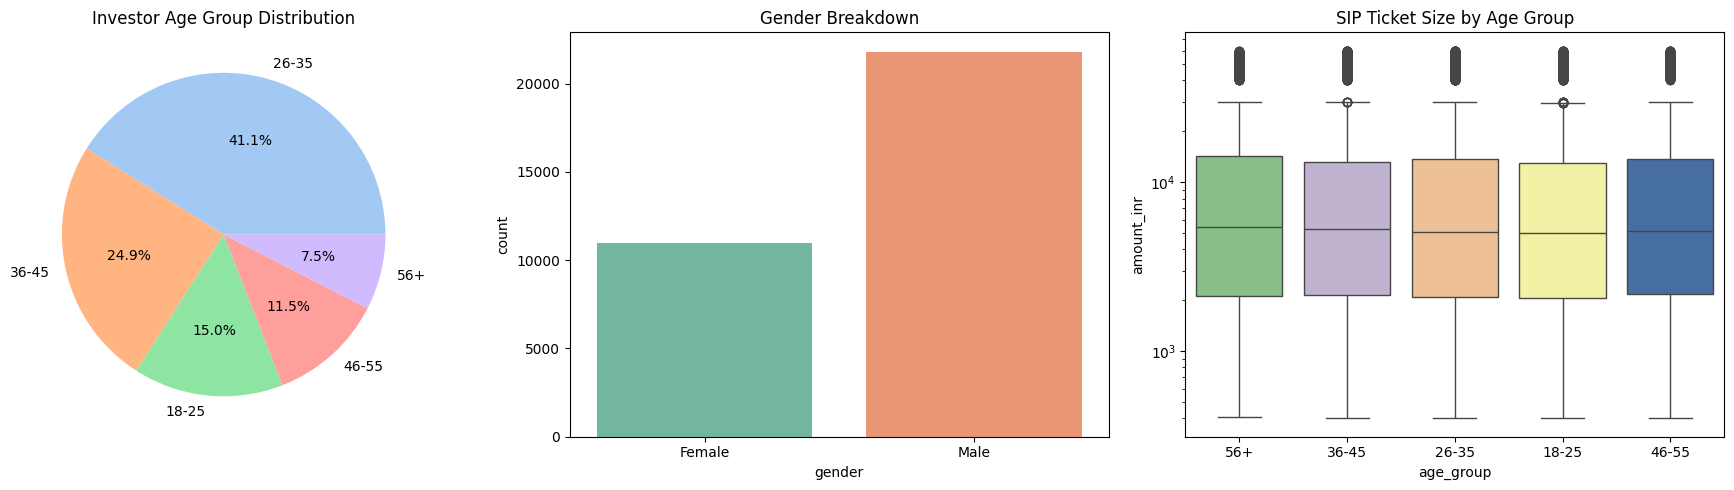

In [ ]:
# Fetch transaction demographic layers
tx_query = "SELECT age_group, gender, amount_inr, transaction_type FROM fact_transactions"
df_users = pd.read_sql(tx_query, conn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age Group Pie Chart
age_counts = df_users['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title('Investor Age Group Distribution')

# 2. Gender Distribution 
sns.countplot(data=df_users, x='gender', ax=axes[1], palette='Set2')
axes[1].set_title('Gender Breakdown')

# 3. SIP Value by Age Bracket
sip_only = df_users[df_users['transaction_type'] == 'SIP']
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', ax=axes[2], palette='Accent')
axes[2].set_title('SIP Ticket Size by Age Group')
axes[2].set_yscale('log') # scaled to handle wide boundaries safely

plt.tight_layout()
plt.savefig('../reports/investor_demographics.png', dpi=300)
plt.show()

### Geographic Distribution Analysis (Matplotlib / Seaborn)

C:\Users\Arjun\AppData\Local\Temp\ipykernel_16804\3423852154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_val.values, y=state_val.index, ax=axes[0], palette='viridis')


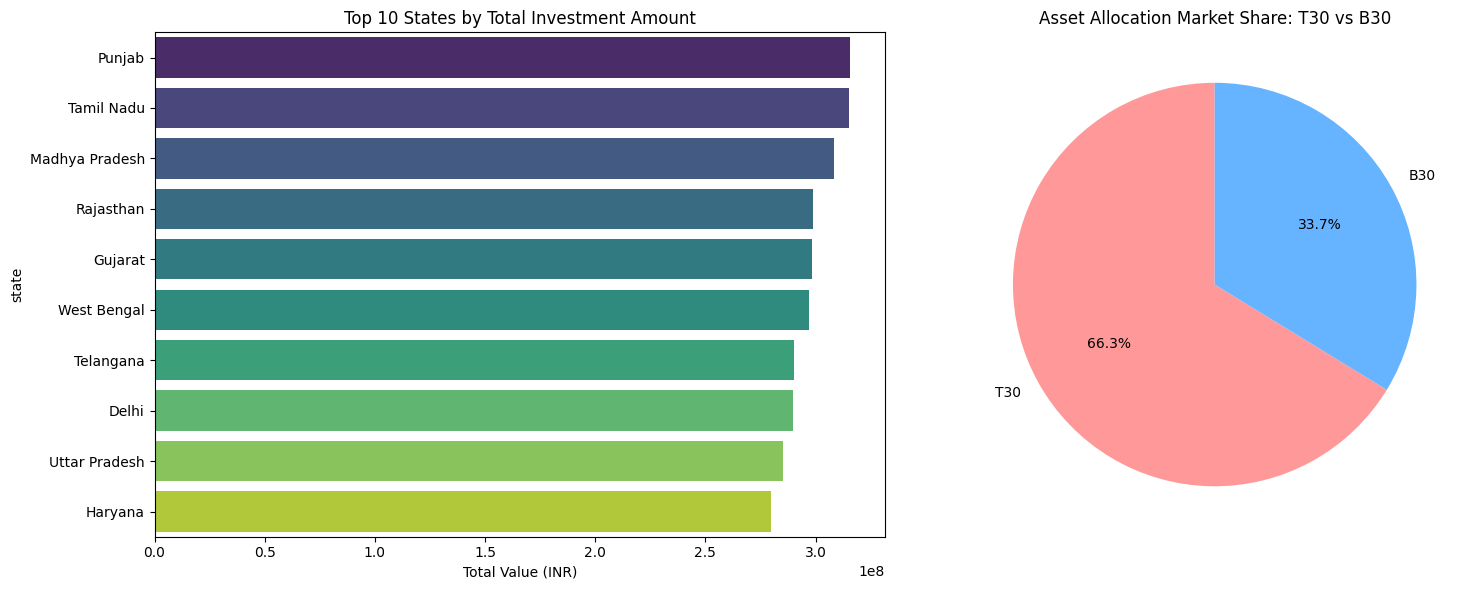

In [ ]:
geo_query = "SELECT state, city_tier, amount_inr FROM fact_transactions"
df_geo = pd.read_sql(geo_query, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Horizontal Bar Chart for States
state_val = df_geo.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_val.values, y=state_val.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 States by Total Investment Amount')
axes[0].set_xlabel('Total Value (INR)')

# 2. T30 vs B30 Tier Class Split
tier_counts = df_geo['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title('Asset Allocation Market Share: T30 vs B30')

plt.tight_layout()
plt.savefig('../reports/geographic_distribution.png', dpi=300)
plt.show()

### Folio Count Growth Line Chart (Matplotlib)

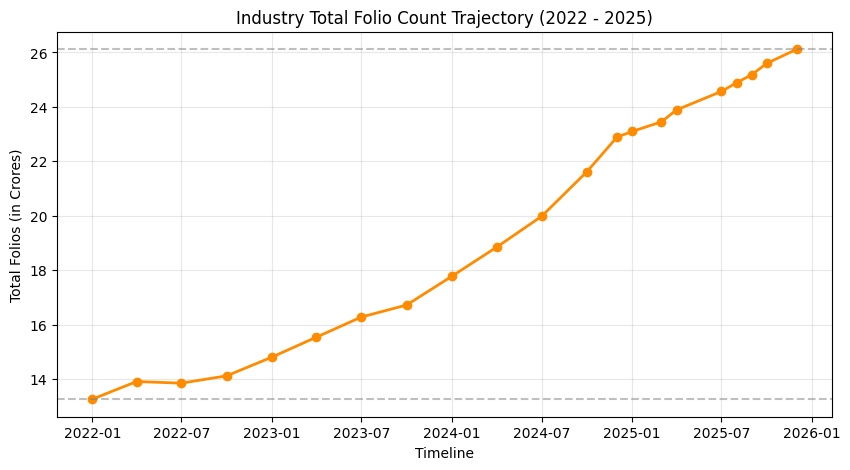

In [9]:
plt.figure(figsize=(10, 5))
folio_df = pd.read_csv('../data/processed/clean_industry_folio_count.csv')
folio_df['month'] = pd.to_datetime(folio_df['month'])

plt.plot(folio_df['month'], folio_df['total_folios_crore'], marker='o', color='darkorange', linewidth=2)

# Mark key start and endpoint milestones explicitly
plt.axhline(y=13.26, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=26.12, color='gray', linestyle='--', alpha=0.5)

plt.title('Industry Total Folio Count Trajectory (2022 - 2025)')
plt.ylabel('Total Folios (in Crores)')
plt.xlabel('Timeline')
plt.grid(True, alpha=0.3)

plt.savefig('../reports/folio_growth.png', dpi=300)
plt.show()

### NAV Daily Return Pairwise Correlation Matrix (Seaborn Heatmap)

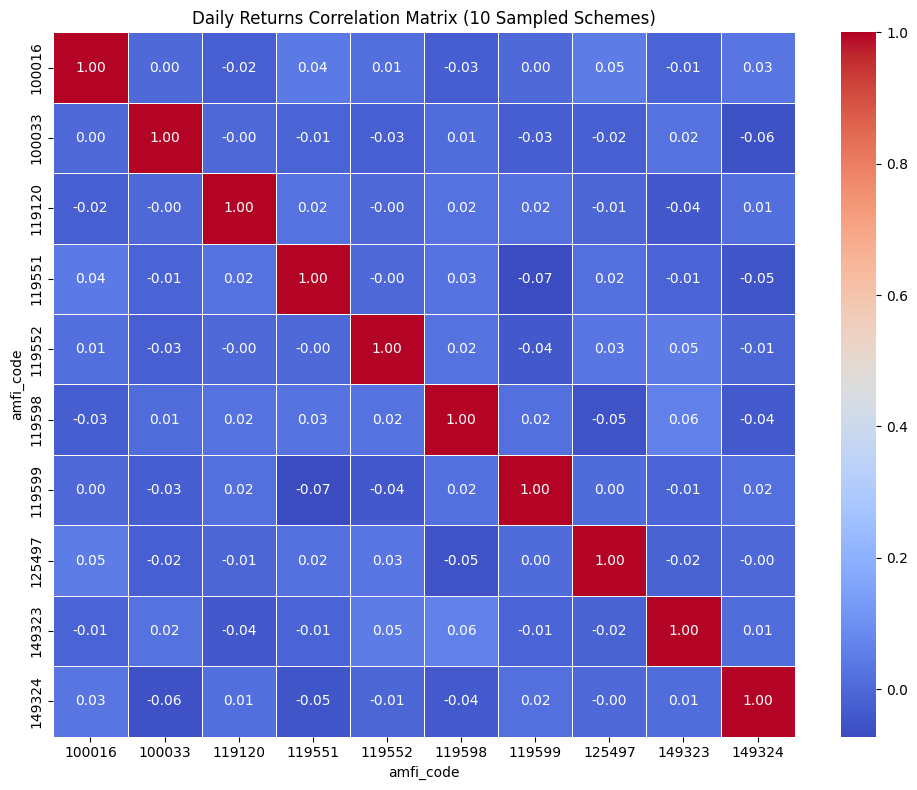

In [10]:
plt.figure(figsize=(10, 8))

# Select 10 fund codes to perform matrix math
selected_funds = [119551, 119552, 119598, 119599, 100016, 125497, 100033, 149323, 149324, 119120]

# Query daily prices
matrix_query = f"SELECT date, amfi_code, nav FROM fact_nav WHERE amfi_code IN ({','.join(map(str, selected_funds))})"
df_matrix = pd.read_sql(matrix_query, conn)

# Pivot so funds form distinct columns
df_pivot = df_matrix.pivot(index='date', columns='amfi_code', values='nav')

# Calculate daily percentage returns
df_returns = df_pivot.pct_change().dropna()

# Compute Pearson correlation matrix
corr_matrix = df_returns.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Daily Returns Correlation Matrix (10 Sampled Schemes)')
plt.tight_layout()

plt.savefig('../reports/nav_correlation.png', dpi=300)
plt.show()

### Sector Allocation Donut Chart (Matplotlib)

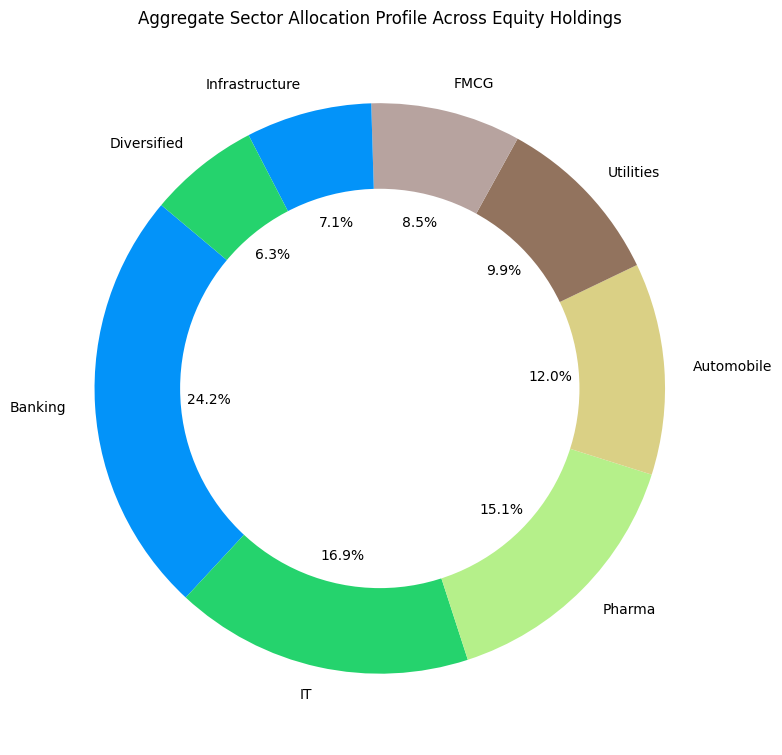

In [11]:
plt.figure(figsize=(8, 8))
holdings_df = pd.read_sql("SELECT sector, weight_pct FROM fact_portfolio", conn)

# Summarize weights across sectors
sector_weights = holdings_df.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(8)

# Build donut chart layout
plt.pie(sector_weights.values, labels=sector_weights.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('terrain'))

# Add the center cutout circle to turn the pie into a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Aggregate Sector Allocation Profile Across Equity Holdings')
plt.tight_layout()

plt.savefig('../reports/sector_donut.png', dpi=300)
plt.show()

# Close the database connection cleanly
conn.close()

###  Key Notes & Takeaways from EDA

* **NAV Growth:** Looking at the charts, most fund NAVs climbed steadily over the 4-year period. The green shaded area shows the strong market run we had in 2023, while the red zone marks where things flattened out or corrected a bit in early 2024.
* **SBI Industry Lead:** The bar chart makes it pretty obvious that SBI Mutual Fund is dominating the space. Their total AUM is way ahead of the others, creeping up toward that massive 12.5L Crore mark by 2025.
* **SIP Momentum:** Retail investor consistency is wild. Total monthly SIP inflows didn't really care about minor market dips—they just kept going up until hitting that peak of ₹31,002 Cr right at the end of 2025.
* **Liquid Fund Usage:** The heatmap intensity shows that Liquid Funds see a lot of heavy, consistent monthly movement compared to specialized or thematic categories, which makes sense for short-term parking of cash.
* **The Core Investor:** Our pie chart shows that 26-35 year olds make up the biggest slice of the user base (over 41%). It looks like young professionals are driving a huge chunk of this digital investment wave.
* **Ticket Size vs Age:** The box plot shows an interesting trend—even though younger folks trade more frequently, the older age brackets (like 46-55) have a higher median ticket size per transaction.
* **Regional Hubs:** Punjab and Tamil Nadu are showing up as major sweet spots for total investment capital in our data, closely followed by states like Madhya Pradesh and Rajasthan.
* **Tier-30 Growth:** The geographic split shows that T30 cities still hold the majority share at 66.3%, but B30 (beyond the top 30 cities) carving out over a third of the market shows massive retail expansion.
* **Folio Explosion:** The overall industry scale practically doubled. Total folios went on a clear, unbroken run from 13.26 Crore all the way up to 26.12 Crore in a four-year frame.
* **Fund Independence:** The return correlation matrix is mostly blue with values near 0.00, meaning individual fund daily returns aren't just blindly copying each other. They move quite independently.
* **Sector Concentration:** Banking (24.2%) and IT (16.9%) take up the lion's share of equity portfolio allocations. Together, they make up more than 40% of where the capital is actually being deployed.